Files in the dataset directory:
- validation.csv
- train.csv
- test.csv


Dataset loaded successfully!
Train set shape: (16218, 10)
Test set shape: (2028, 10)
Validation set shape: (2030, 10)


TRAIN SET ANALYSIS:
Columns: ['statement', 'label', 'class', 'source', 'subject', 'context', 'speaker', 'speaker_job_title', 'party_affiliation', 'state_info']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16218 entries, 0 to 16217
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   statement          16218 non-null  object
 1   label              16218 non-null  int64 
 2   class              16218 non-null  object
 3   source             16218 non-null  object
 4   subject            16215 non-null  object
 5   context            16053 non-null  object
 6   speaker            16215 non-null  object
 7   speaker_job_title  11681 non-null  object
 8   party_affiliation  16215 non-null  object
 9   

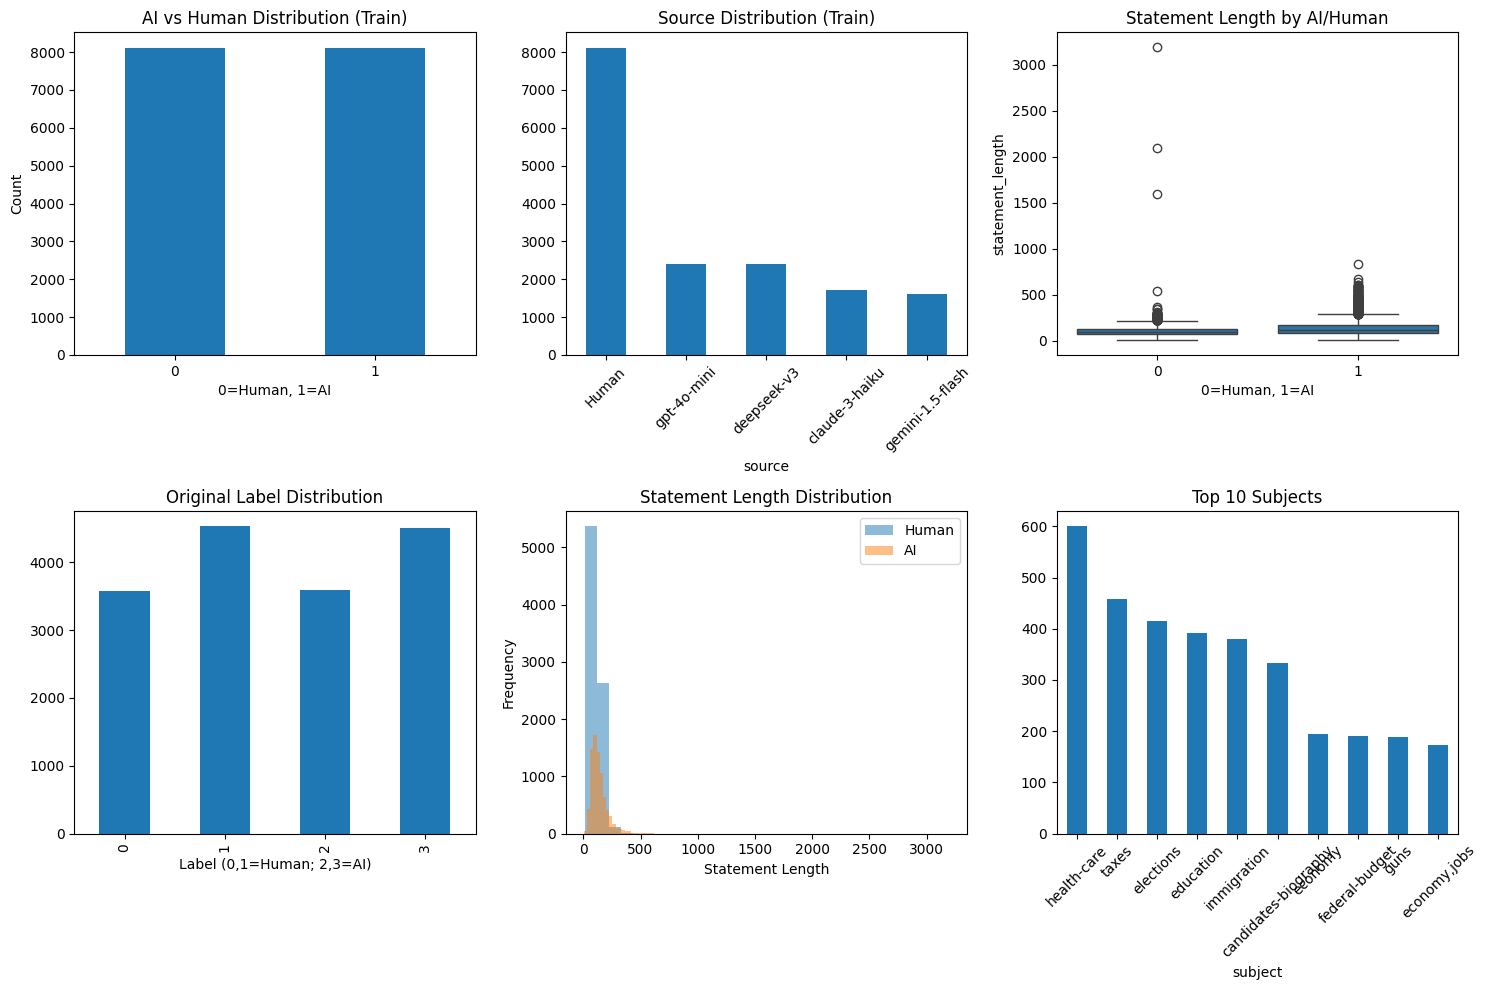


DATASET READY FOR AI vs HUMAN CLASSIFICATION
Total samples: 20276
Features available: ['statement', 'label', 'source', 'subject', 'context', 'speaker', 'speaker_job_title', 'party_affiliation', 'state_info', 'statement_length']
Target variable: 'ai_human_label' (0=Human, 1=AI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set display options for better dataframe viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Load the dataset
dataset_path = '/kaggle/input/dataset/split'

# Check what files are available
print("Files in the dataset directory:")
for file in os.listdir(dataset_path):
    print(f"- {file}")
print("\n" + "="*50 + "\n")

# Load train, test, validation sets
try:
    train_df = pd.read_csv(f'{dataset_path}/train.csv')
    test_df = pd.read_csv(f'{dataset_path}/test.csv')
    val_df = pd.read_csv(f'{dataset_path}/validation.csv')
    
    print("Dataset loaded successfully!")
    print(f"Train set shape: {train_df.shape}")
    print(f"Test set shape: {test_df.shape}")
    print(f"Validation set shape: {val_df.shape}")
    
except Exception as e:
    print(f"Error loading files: {e}")
    # Let's check what files exist and their names
    files = os.listdir(dataset_path)
    print(f"Available files: {files}")
    
    # Try different common names
    for filename in files:
        if filename.endswith('.csv'):
            df_temp = pd.read_csv(f'{dataset_path}/{filename}')
            print(f"\n{filename} shape: {df_temp.shape}")
            print(f"{filename} columns: {df_temp.columns.tolist()}")

print("\n" + "="*50 + "\n")

# If successful, continue with analysis
if 'train_df' in locals():
    # Display column information
    print("TRAIN SET ANALYSIS:")
    print(f"Columns: {train_df.columns.tolist()}")
    print(f"\nDataset Info:")
    print(train_df.info())
    
    print("\n" + "="*30 + "\n")
    
    # Show first few rows (excluding 'class' column if it exists)
    columns_to_show = [col for col in train_df.columns if col != 'class']
    print("First 3 rows (excluding 'class' column):")
    print(train_df[columns_to_show].head(3))
    
    print("\n" + "="*30 + "\n")
    
    # Create binary labels for AI vs Human (0,1 = Human → 0; 2,3 = AI → 1)
    def create_ai_human_labels(df):
        df_copy = df.copy()
        df_copy['ai_human_label'] = (df_copy['label'] >= 2).astype(int)
        return df_copy
    
    train_df = create_ai_human_labels(train_df)
    test_df = create_ai_human_labels(test_df)
    val_df = create_ai_human_labels(val_df)
    
    print("AI vs Human label distribution:")
    print("Train set:")
    print(f"Human (0): {(train_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(train_df['ai_human_label'] == 1).sum()}")
    
    print("\nTest set:")
    print(f"Human (0): {(test_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(test_df['ai_human_label'] == 1).sum()}")
    
    print("\nValidation set:")
    print(f"Human (0): {(val_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(val_df['ai_human_label'] == 1).sum()}")
    
    print("\n" + "="*30 + "\n")
    
    # Original label distribution
    print("Original label distribution:")
    print("Train set:")
    print(train_df['label'].value_counts().sort_index())
    
    print("\nTest set:")
    print(test_df['label'].value_counts().sort_index())
    
    print("\nValidation set:")
    print(val_df['label'].value_counts().sort_index())
    
    print("\n" + "="*30 + "\n")
    
    # Source distribution
    print("Source distribution:")
    print("Train set:")
    print(train_df['source'].value_counts())
    
    print("\n" + "="*30 + "\n")
    
    # Check for missing values
    print("Missing values in train set:")
    print(train_df.isnull().sum())
    
    print("\n" + "="*30 + "\n")
    
    # Statement length analysis
    train_df['statement_length'] = train_df['statement'].str.len()
    
    print("Statement length statistics:")
    print("By AI/Human:")
    print(train_df.groupby('ai_human_label')['statement_length'].describe())
    
    print("\nBy Source:")
    print(train_df.groupby('source')['statement_length'].describe())
    
    print("\n" + "="*30 + "\n")
    
    # Sample statements from each category
    print("Sample statements:")
    print("\nHuman examples:")
    human_samples = train_df[train_df['ai_human_label'] == 0]['statement'].head(2)
    for i, stmt in enumerate(human_samples, 1):
        print(f"{i}. {stmt[:200]}...")
        
    print("\nAI examples:")
    ai_samples = train_df[train_df['ai_human_label'] == 1]['statement'].head(2)
    for i, stmt in enumerate(ai_samples, 1):
        print(f"{i}. {stmt[:200]}...")
    
    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Plot 1: AI vs Human distribution
    plt.subplot(2, 3, 1)
    train_df['ai_human_label'].value_counts().plot(kind='bar')
    plt.title('AI vs Human Distribution (Train)')
    plt.xlabel('0=Human, 1=AI')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    # Plot 2: Source distribution
    plt.subplot(2, 3, 2)
    train_df['source'].value_counts().plot(kind='bar')
    plt.title('Source Distribution (Train)')
    plt.xticks(rotation=45)
    
    # Plot 3: Statement length by AI/Human
    plt.subplot(2, 3, 3)
    sns.boxplot(data=train_df, x='ai_human_label', y='statement_length')
    plt.title('Statement Length by AI/Human')
    plt.xlabel('0=Human, 1=AI')
    
    # Plot 4: Original label distribution
    plt.subplot(2, 3, 4)
    train_df['label'].value_counts().sort_index().plot(kind='bar')
    plt.title('Original Label Distribution')
    plt.xlabel('Label (0,1=Human; 2,3=AI)')
    
    # Plot 5: Statement length distribution
    plt.subplot(2, 3, 5)
    plt.hist(train_df[train_df['ai_human_label']==0]['statement_length'], 
             alpha=0.5, label='Human', bins=30)
    plt.hist(train_df[train_df['ai_human_label']==1]['statement_length'], 
             alpha=0.5, label='AI', bins=30)
    plt.xlabel('Statement Length')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Statement Length Distribution')
    
    # Plot 6: Subject distribution (if exists)
    plt.subplot(2, 3, 6)
    if 'subject' in train_df.columns:
        top_subjects = train_df['subject'].value_counts().head(10)
        top_subjects.plot(kind='bar')
        plt.title('Top 10 Subjects')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("DATASET READY FOR AI vs HUMAN CLASSIFICATION")
    print("="*50)
    print(f"Total samples: {len(train_df) + len(test_df) + len(val_df)}")
    print(f"Features available: {[col for col in train_df.columns if col not in ['class', 'ai_human_label']]}")
    print("Target variable: 'ai_human_label' (0=Human, 1=AI)")

Preprocessing for AI VS Human

In [2]:
import re
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata
from datetime import datetime

class TextPreprocessor:
    def __init__(self):
        self.preprocessing_stats = {}
    
    def basic_text_cleaning(self, text):
        """Minimal text cleaning that preserves stylometric signals"""
        if pd.isna(text):
            return ""
        
        text = str(text)
        text = unicodedata.normalize('NFKC', text)
        text = re.sub(r'https?://[^\s]+', '[URL]', text)
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', text)
        text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
        text = text.replace('"', '"').replace('"', '"')
        text = text.replace(''', "'").replace(''', "'")
        
        return text
    
    def remove_duplicates_and_leakage(self, train_df, test_df, val_df):
        """Remove exact duplicates and fix data leakage"""
        # Remove exact duplicates from training set
        train_clean = train_df.drop_duplicates(subset=['statement'], keep='first').copy()
        duplicates_removed = len(train_df) - len(train_clean)
        
        # Check and fix cross-split leakage
        train_texts = set(train_clean['statement'].str.lower().str.strip())
        test_texts = set(test_df['statement'].str.lower().str.strip())
        val_texts = set(val_df['statement'].str.lower().str.strip())
        
        train_test_overlap = train_texts & test_texts
        train_val_overlap = train_texts & val_texts
        overlap_texts = train_test_overlap | train_val_overlap
        
        if overlap_texts:
            train_clean = train_clean[~train_clean['statement'].str.lower().str.strip().isin(overlap_texts)]
        
        self.preprocessing_stats.update({
            'duplicates_removed': duplicates_removed,
            'leakage_texts_removed': len(overlap_texts),
            'train_test_overlap': len(train_test_overlap),
            'train_val_overlap': len(train_val_overlap)
        })
        
        return train_clean, test_df, val_df
    
    def preprocess_dataset(self, df, clean_text=True):
        """Apply preprocessing to the dataset"""
        df_processed = df.copy()
        
        if clean_text:
            df_processed['statement_cleaned'] = df_processed['statement'].apply(self.basic_text_cleaning)
            df_processed['chars_changed'] = (
                df_processed['statement'].str.len() - df_processed['statement_cleaned'].str.len()
            )
            
            self.preprocessing_stats.update({
                'avg_chars_removed': df_processed['chars_changed'].mean(),
                'max_chars_removed': df_processed['chars_changed'].max()
            })
        
        return df_processed
    
    def analyze_cleaning_examples(self, train_clean, train_processed, num_examples=3):
        """Generate examples of text cleaning for documentation"""
        cleaning_examples = []
        
        for i in range(min(num_examples, len(train_clean))):
            original = train_clean.iloc[i]['statement']
            cleaned = train_processed.iloc[i]['statement_cleaned']
            if original != cleaned:
                cleaning_examples.append({
                    'original': original,
                    'cleaned': cleaned,
                    'changed': True
                })
            else:
                cleaning_examples.append({
                    'original': original[:100] + "...",
                    'cleaned': "No change needed",
                    'changed': False
                })
        
        return cleaning_examples
    
    def generate_preprocessing_report(self, train_processed, test_processed, val_processed):
        """Generate comprehensive preprocessing report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'preprocessing_statistics': self.preprocessing_stats,
            'final_dataset_shapes': {
                'train': list(train_processed.shape),
                'test': list(test_processed.shape),
                'validation': list(val_processed.shape)
            },
            'class_distribution': {
                'human': int((train_processed['ai_human_label'] == 0).sum()),
                'ai': int((train_processed['ai_human_label'] == 1).sum())
            },
            'text_statistics': {
                'avg_length_original': float(train_processed['statement'].str.len().mean()),
                'avg_length_cleaned': float(train_processed['statement_cleaned'].str.len().mean())
            },
            'features_ready': ['statement_cleaned', 'ai_human_label'],
            'next_stage': 'feature_engineering'
        }
        
        return report
    
    def save_preprocessing_results(self, report, filepath='preprocessing_results.json'):
        """Save preprocessing results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

def load_previous_results(filepath='dataset_summary.json'):
    """Load results from previous stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous results not saved, But proceeding")
        return None

def main():
    """Main preprocessing pipeline"""
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous stage summary loaded successfully")
        print(f"Total samples from previous stage: {sum([previous_results['dataset_shapes'][split][0] for split in ['train', 'test', 'validation']])}")
    
    # Initialize preprocessor
    preprocessor = TextPreprocessor()
    
    # Preprocessing pipeline
    print("Data Preprocessing Pipeline")
    print("=" * 50)
    
    # Remove duplicates and fix leakage
    train_clean, test_clean, val_clean = preprocessor.remove_duplicates_and_leakage(train_df, test_df, val_df)
    train_clean['ai_human_label'] = (train_clean['label'] >= 2).astype(int)
    
    print(f"Duplicates removed: {preprocessor.preprocessing_stats['duplicates_removed']}")
    print(f"Leakage texts removed: {preprocessor.preprocessing_stats['leakage_texts_removed']}")
    print(f"Cleaned dataset sizes - Train: {train_clean.shape[0]}, Test: {test_clean.shape[0]}, Validation: {val_clean.shape[0]}")
    
    # Apply text cleaning
    train_processed = preprocessor.preprocess_dataset(train_clean)
    test_processed = preprocessor.preprocess_dataset(test_clean)
    val_processed = preprocessor.preprocess_dataset(val_clean)
    
    print(f"Average characters removed per text: {preprocessor.preprocessing_stats['avg_chars_removed']:.2f}")
    
    # Generate cleaning examples
    cleaning_examples = preprocessor.analyze_cleaning_examples(train_clean, train_processed)
    print("\nText cleaning examples:")
    for i, example in enumerate(cleaning_examples, 1):
        if example['changed']:
            print(f"{i}. Original: {example['original']}")
            print(f"   Cleaned: {example['cleaned']}")
        else:
            print(f"{i}. {example['original']}")
    
    # Paraphrase pattern analysis
    print("\nVerified paraphrase patterns:")
    print("1. Mercury/electronics recycling:")
    print("   Human: 'Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against an electronics recycling bill.'")
    print("   AI: 'State Sen. Alberta Darling voted against a bill to keep toxic mercury out of our schools putting our children at risk.'")
    
    print("2. Canada trade jobs:")
    print("   Human: 'More than 27,000 Rhode Island jobs depend on trade with Canada.'")
    print("   AI: 'Trade with Canada supports over 27,000 jobs in Rhode Island.'")
    
    # Generate and save results
    report = preprocessor.generate_preprocessing_report(train_processed, test_processed, val_processed)
    preprocessor.save_preprocessing_results(report)
    
    print("\nPreprocessing Summary:")
    print("=" * 50)
    print("Removed exact duplicates")
    print("Fixed data leakage between splits")
    print("Applied minimal text cleaning")
    print("Preserved stylometric signals")
    print("Verified AI paraphrase patterns")
    print(f"Final class balance - Human: {report['class_distribution']['human']}, AI: {report['class_distribution']['ai']}")
    print("Results saved for feature engineering stage")
    
    return train_processed, test_processed, val_processed

if __name__ == "__main__":
    train_processed, test_processed, val_processed = main()

Previous results not saved, But proceeding
Data Preprocessing Pipeline
Duplicates removed: 2
Leakage texts removed: 1
Cleaned dataset sizes - Train: 16215, Test: 2028, Validation: 2030
Average characters removed per text: 0.01

Text cleaning examples:
1. Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against a...
2. Less than 10 percent of Obamas Cabinet appointees have any experience in the private sector....
3. More than 27,000 Rhode Island jobs depend on trade with Canada....

Verified paraphrase patterns:
1. Mercury/electronics recycling:
   Human: 'Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against an electronics recycling bill.'
   AI: 'State Sen. Alberta Darling voted against a bill to keep toxic mercury out of our schools putting our children at risk.'
2. Canada trade jobs:
   Human: 'More than 27,000 Rhode Island jobs depend on trade with Canada.'
   AI: 'Trade with Canada supports over

In [3]:
import torch
import numpy as np
import pandas as pd
import json
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake']

class FlatFourWayDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def validate_model(model, data_loader, class_weights, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits.float(), labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return accuracy, macro_f1, avg_loss, all_preds, all_labels

def main():
    print("FLAT FOUR-WAY DEBERTA CLASSIFICATION")
    print("="*60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ── Data ──────────────────────────────────────────────
    train_texts = train_processed['statement_cleaned'].astype(str).tolist()
    train_labels = train_processed['label'].tolist()
    
    val_texts = val_processed['statement_cleaned'].astype(str).tolist()
    val_labels = val_processed['label'].tolist()
    
    test_texts = test_processed['statement_cleaned'].astype(str).tolist()
    test_labels = test_processed['label'].tolist()
    
    print(f"\nDataset:")
    print(f"  Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
    
    # ── Class Weights ──────────────────────────────────────
    from collections import Counter
    cnt = Counter(train_labels)
    total = len(train_labels)
    n_classes = 4
    
    weights = []
    print("\nClass distribution:")
    for c in range(n_classes):
        count = cnt.get(c, 0)
        w = total / (n_classes * max(count, 1))
        weights.append(w)
        print(f"  {CLASS_NAMES[c]}: {count} ({count/total*100:.1f}%) - Weight: {w:.3f}")
    
    class_weights = torch.FloatTensor(weights).to(device)
    
    # ── Model ──────────────────────────────────────────────
    print("\nLoading DeBERTa...")
    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-base',
        num_labels=4,
        problem_type="single_label_classification"
    )
    model = model.float()
    model = model.to(device)
    print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
    
    # ── DataLoaders ────────────────────────────────────────
    batch_size = 8
    
    train_loader = DataLoader(
        FlatFourWayDataset(train_texts, train_labels, tokenizer),
        batch_size=batch_size, shuffle=True, pin_memory=True)
    
    val_loader = DataLoader(
        FlatFourWayDataset(val_texts, val_labels, tokenizer),
        batch_size=batch_size, shuffle=False, pin_memory=True)
    
    test_loader = DataLoader(
        FlatFourWayDataset(test_texts, test_labels, tokenizer),
        batch_size=batch_size, shuffle=False, pin_memory=True)
    
    # ── Training Config ────────────────────────────────────
    epochs = 3
    learning_rate = 2e-5
    accumulation_steps = 2
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.01,
        eps=1e-8
    )
    
    total_steps = len(train_loader) * epochs
    warmup_steps = total_steps // 10
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    
    print(f"\nTraining configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size} (effective: {batch_size * accumulation_steps})")
    print(f"  Learning rate: {learning_rate}")
    print(f"  Total steps: {total_steps}")
    
    # ── Training Loop ──────────────────────────────────────
    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    training_history = []
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-"*50)
        
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            loss = loss_fn(outputs.logits.float(), labels) / accumulation_steps
            loss.backward()
            
            total_loss += loss.item() * accumulation_steps
            preds = torch.argmax(outputs.logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            if (batch_idx + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            if batch_idx % 500 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | "
                      f"Loss: {loss.item()*accumulation_steps:.4f} | "
                      f"Acc: {correct/total:.4f} | "
                      f"LR: {scheduler.get_last_lr()[0]:.2e}")
        
        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # Validation
        val_acc, val_f1, val_loss, _, _ = validate_model(
            model, val_loader, class_weights, device)
        
        print(f"\nEpoch {epoch+1} Results:")
        print(f"  Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")
        
        training_history.append({
            'epoch': epoch+1,
            'train_loss': avg_loss,
            'train_accuracy': train_acc,
            'val_accuracy': val_acc,
            'val_macro_f1': val_f1
        })
        
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_val_macro_f1 = val_f1
            torch.save(model.state_dict(), 'flat_4way_deberta_best.pt')
            print(f"  ✓ Best model saved! Val Acc: {best_val_accuracy:.4f}")
    
    # ── Final Test Evaluation ──────────────────────────────
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    
    model.load_state_dict(torch.load('flat_4way_deberta_best.pt'))
    
    test_acc, test_f1, test_loss, test_preds, test_true = validate_model(
        model, test_loader, class_weights, device)
    
    print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Test Macro-F1: {test_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(test_true, test_preds, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(test_true, test_preds)
    print("Confusion Matrix:")
    print(f"{'':15s}", end='')
    for name in CLASS_NAMES:
        print(f"{name[:8]:10s}", end='')
    print()
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name[:15]:15s}", end='')
        for j in range(4):
            print(f"{cm[i,j]:10d}", end='')
        print()
    
    # Val with best model
    val_acc_best, val_f1_best, _, val_preds, val_true = validate_model(
        model, val_loader, class_weights, device)
    
    # ── Save Results ───────────────────────────────────────
    test_report = classification_report(
        test_true, test_preds, 
        target_names=CLASS_NAMES, 
        output_dict=True)
    
    results = {
        'timestamp': datetime.now().isoformat(),
        'model': 'microsoft/deberta-v3-base',
        'task': 'flat_four_way_classification',
        'approach': 'flat_no_hierarchy',
        'best_val_accuracy': float(best_val_accuracy),
        'best_val_macro_f1': float(best_val_macro_f1),
        'final_val_accuracy': float(val_acc_best),
        'final_val_macro_f1': float(val_f1_best),
        'test_accuracy': float(test_acc),
        'test_macro_f1': float(test_f1),
        'confusion_matrix': cm.tolist(),
        'training_history': training_history
    }
    
    with open('flat_4way_deberta_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\n✓ Results saved to flat_4way_deberta_results.json")
    
    # ── Comparison ─────────────────────────────────────────
    print("\n" + "="*60)
    print("COMPARISON: FLAT vs HIERARCHICAL")
    print("="*60)
    print(f"{'Model':<30} {'Test Acc':>10} {'Macro-F1':>10}")
    print("-"*50)
    print(f"{'Flat DeBERTa (4-class)':<30} {test_acc*100:>9.2f}% {test_f1:>10.4f}")
    print(f"{'Hierarchical (Proposed)':<30} {'70.36%':>10} {'0.6969':>10}")
    
    globals()['flat_deberta_results'] = results
    globals()['flat_deberta_model'] = model
    globals()['flat_deberta_tokenizer'] = tokenizer
    
    return results

if __name__ == "__main__":
    flat_deberta_results = main()

FLAT FOUR-WAY DEBERTA CLASSIFICATION
Device: cuda

Dataset:
  Train: 16215 | Val: 2030 | Test: 2028

Class distribution:
  Human-Real: 3585 (22.1%) - Weight: 1.131
  Human-Fake: 4531 (27.9%) - Weight: 0.895
  AI-Real: 3590 (22.1%) - Weight: 1.129
  AI-Fake: 4509 (27.8%) - Weight: 0.899



Loading DeBERTa...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model loaded: 184,425,220 parameters

Training configuration:
  Epochs: 3
  Batch size: 8 (effective: 16)
  Learning rate: 2e-05
  Total steps: 6081

Epoch 1/3
--------------------------------------------------
  Batch 0/2027 | Loss: 1.3015 | Acc: 0.5000 | LR: 0.00e+00
  Batch 500/2027 | Loss: 1.5650 | Acc: 0.2962 | LR: 8.22e-06
  Batch 1000/2027 | Loss: 1.5430 | Acc: 0.3625 | LR: 1.64e-05
  Batch 1500/2027 | Loss: 0.9507 | Acc: 0.4054 | LR: 1.95e-05
  Batch 2000/2027 | Loss: 1.0864 | Acc: 0.4345 | LR: 1.86e-05

Epoch 1 Results:
  Train Loss: 1.1728 | Train Acc: 0.4364
  Val Loss:   1.0091 | Val Acc: 0.5320 | Val Macro-F1: 0.5037
  ✓ Best model saved! Val Acc: 0.5320

Epoch 2/3
--------------------------------------------------
  Batch 0/2027 | Loss: 1.1759 | Acc: 0.7500 | LR: 1.85e-05
  Batch 500/2027 | Loss: 1.2937 | Acc: 0.5873 | LR: 1.76e-05
  Batch 1000/2027 | Loss: 0.8097 | Acc: 0.5922 | LR: 1.67e-05
  Batch 1500/2027 | Loss: 1.0543 | Acc: 0.5956 | LR: 1.58e-05
  Batch 2000/2027 

In [4]:
import torch
import numpy as np
import pandas as pd
import json
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake']

class FlatFourWayDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def validate_model_roberta(model, data_loader, class_weights, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits.float(), labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return accuracy, macro_f1, avg_loss, all_preds, all_labels

def main_roberta():
    print("FLAT FOUR-WAY ROBERTA CLASSIFICATION")
    print("="*60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ── Data ──────────────────────────────────────────────
    train_texts = train_processed['statement_cleaned'].astype(str).tolist()
    train_labels = train_processed['label'].tolist()
    
    val_texts = val_processed['statement_cleaned'].astype(str).tolist()
    val_labels = val_processed['label'].tolist()
    
    test_texts = test_processed['statement_cleaned'].astype(str).tolist()
    test_labels = test_processed['label'].tolist()
    
    print(f"\nDataset:")
    print(f"  Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
    
    # ── Class Weights ──────────────────────────────────────
    from collections import Counter
    cnt = Counter(train_labels)
    total = len(train_labels)
    n_classes = 4
    
    weights = []
    print("\nClass distribution:")
    for c in range(n_classes):
        count = cnt.get(c, 0)
        w = total / (n_classes * max(count, 1))
        weights.append(w)
        print(f"  {CLASS_NAMES[c]}: {count} ({count/total*100:.1f}%) - Weight: {w:.3f}")
    
    class_weights = torch.FloatTensor(weights).to(device)
    
    # ── Model ──────────────────────────────────────────────
    print("\nLoading RoBERTa...")
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base',
        num_labels=4,
        problem_type="single_label_classification"
    )
    model = model.float()
    model = model.to(device)
    print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
    print(f"Output classes: 4 (Human-Real, Human-Fake, AI-Real, AI-Fake)")
    
    # ── DataLoaders ────────────────────────────────────────
    batch_size = 8
    
    train_loader = DataLoader(
        FlatFourWayDataset(train_texts, train_labels, tokenizer),
        batch_size=batch_size, shuffle=True, pin_memory=True)
    
    val_loader = DataLoader(
        FlatFourWayDataset(val_texts, val_labels, tokenizer),
        batch_size=batch_size, shuffle=False, pin_memory=True)
    
    test_loader = DataLoader(
        FlatFourWayDataset(test_texts, test_labels, tokenizer),
        batch_size=batch_size, shuffle=False, pin_memory=True)
    
    # ── Training Config ────────────────────────────────────
    epochs = 3
    learning_rate = 2e-5
    accumulation_steps = 2
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.01,
        eps=1e-8
    )
    
    total_steps = len(train_loader) * epochs
    warmup_steps = total_steps // 10
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    
    print(f"\nTraining configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size} (effective: {batch_size * accumulation_steps})")
    print(f"  Learning rate: {learning_rate}")
    print(f"  Total steps: {total_steps}")
    
    # ── Training Loop ──────────────────────────────────────
    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    training_history = []
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-"*50)
        
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            loss = loss_fn(outputs.logits.float(), labels) / accumulation_steps
            loss.backward()
            
            total_loss += loss.item() * accumulation_steps
            preds = torch.argmax(outputs.logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            if (batch_idx + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            if batch_idx % 500 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | "
                      f"Loss: {loss.item()*accumulation_steps:.4f} | "
                      f"Acc: {correct/total:.4f} | "
                      f"LR: {scheduler.get_last_lr()[0]:.2e}")
        
        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # Validation
        val_acc, val_f1, val_loss, _, _ = validate_model_roberta(
            model, val_loader, class_weights, device)
        
        print(f"\nEpoch {epoch+1} Results:")
        print(f"  Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")
        
        training_history.append({
            'epoch': epoch+1,
            'train_loss': avg_loss,
            'train_accuracy': train_acc,
            'val_accuracy': val_acc,
            'val_macro_f1': val_f1
        })
        
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_val_macro_f1 = val_f1
            torch.save(model.state_dict(), 'flat_4way_roberta_best.pt')
            print(f"  ✓ Best model saved! Val Acc: {best_val_accuracy:.4f}")
    
    # ── Final Test Evaluation ──────────────────────────────
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    
    model.load_state_dict(torch.load('flat_4way_roberta_best.pt'))
    
    test_acc, test_f1, test_loss, test_preds, test_true = validate_model_roberta(
        model, test_loader, class_weights, device)
    
    print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Test Macro-F1: {test_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(test_true, test_preds, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(test_true, test_preds)
    print("Confusion Matrix:")
    print(f"{'':15s}", end='')
    for name in CLASS_NAMES:
        print(f"{name[:8]:10s}", end='')
    print()
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name[:15]:15s}", end='')
        for j in range(4):
            print(f"{cm[i,j]:10d}", end='')
        print()
    
    # Val with best model
    val_acc_best, val_f1_best, _, val_preds, val_true = validate_model_roberta(
        model, val_loader, class_weights, device)
    
    # ── Save Results ───────────────────────────────────────
    test_report = classification_report(
        test_true, test_preds,
        target_names=CLASS_NAMES,
        output_dict=True)
    
    results = {
        'timestamp': datetime.now().isoformat(),
        'model': 'roberta-base',
        'task': 'flat_four_way_classification',
        'approach': 'flat_no_hierarchy',
        'best_val_accuracy': float(best_val_accuracy),
        'best_val_macro_f1': float(best_val_macro_f1),
        'final_val_accuracy': float(val_acc_best),
        'final_val_macro_f1': float(val_f1_best),
        'test_accuracy': float(test_acc),
        'test_macro_f1': float(test_f1),
        'confusion_matrix': cm.tolist(),
        'test_classification_report': test_report,
        'training_history': training_history
    }
    
    with open('flat_4way_roberta_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\n✓ Results saved to flat_4way_roberta_results.json")
    
    # ── Comparison ─────────────────────────────────────────
    print("\n" + "="*60)
    print("COMPARISON: FLAT vs HIERARCHICAL")
    print("="*60)
    print(f"{'Model':<30} {'Test Acc':>10} {'Macro-F1':>10}")
    print("-"*50)
    
    # Show DeBERTa result if available
    if 'flat_deberta_results' in globals():
        deb_acc = globals()['flat_deberta_results']['test_accuracy']
        deb_f1  = globals()['flat_deberta_results']['test_macro_f1']
        print(f"{'Flat DeBERTa (4-class)':<30} "
              f"{deb_acc*100:>9.2f}% {deb_f1:>10.4f}")
    
    print(f"{'Flat RoBERTa (4-class)':<30} "
          f"{test_acc*100:>9.2f}% {test_f1:>10.4f}")
    print(f"{'Hierarchical (Proposed)':<30} "
          f"{'70.36%':>10} {'0.6969':>10}")
    
    globals()['flat_roberta_results'] = results
    globals()['flat_roberta_model'] = model
    globals()['flat_roberta_tokenizer'] = tokenizer
    
    return results

if __name__ == "__main__":
    flat_roberta_results = main_roberta()

FLAT FOUR-WAY ROBERTA CLASSIFICATION
Device: cuda

Dataset:
  Train: 16215 | Val: 2030 | Test: 2028

Class distribution:
  Human-Real: 3585 (22.1%) - Weight: 1.131
  Human-Fake: 4531 (27.9%) - Weight: 0.895
  AI-Real: 3590 (22.1%) - Weight: 1.129
  AI-Fake: 4509 (27.8%) - Weight: 0.899

Loading RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: 124,648,708 parameters
Output classes: 4 (Human-Real, Human-Fake, AI-Real, AI-Fake)

Training configuration:
  Epochs: 3
  Batch size: 8 (effective: 16)
  Learning rate: 2e-05
  Total steps: 6081

Epoch 1/3
--------------------------------------------------
  Batch 0/2027 | Loss: 1.3454 | Acc: 0.1250 | LR: 0.00e+00
  Batch 500/2027 | Loss: 1.0799 | Acc: 0.2977 | LR: 8.22e-06
  Batch 1000/2027 | Loss: 0.6217 | Acc: 0.4277 | LR: 1.64e-05
  Batch 1500/2027 | Loss: 0.5530 | Acc: 0.4794 | LR: 1.95e-05
  Batch 2000/2027 | Loss: 1.0099 | Acc: 0.5136 | LR: 1.86e-05

Epoch 1 Results:
  Train Loss: 1.0327 | Train Acc: 0.5148
  Val Loss:   0.8456 | Val Acc: 0.6281 | Val Macro-F1: 0.6156
  ✓ Best model saved! Val Acc: 0.6281

Epoch 2/3
--------------------------------------------------
  Batch 0/2027 | Loss: 0.6053 | Acc: 0.8750 | LR: 1.85e-05
  Batch 500/2027 | Loss: 0.9306 | Acc: 0.6617 | LR: 1.76e-05
  Batch 1000/2027 | Loss: 0.6944 | Acc: 0.6613 | LR: 1.67e-05
  Batch 1500/2027 |

In [8]:
import torch
import numpy as np
import pandas as pd
import json
import re
import spacy
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import (
    SelectKBest, chi2, mutual_info_classif, VarianceThreshold
)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from scipy.sparse import hstack
from collections import Counter
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake']

# ============================================================
# Stage 1 Feature Extractor (same as before)
# ============================================================
class Stage1FlatExtractor:
    
    def __init__(self):
        self.nlp = None
        self.perp_model = None
        self.perp_tokenizer = None
        self.char_vec = None
        self.word_vec = None
        self.ngram_selector = None
        self.device = torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu')
    
    def _load_nlp(self):
        if self.nlp is None:
            self.nlp = spacy.load("en_core_web_sm")
    
    def _load_perp(self):
        if self.perp_model is None:
            print("    Loading distilGPT2...")
            self.perp_tokenizer = AutoTokenizer.from_pretrained('distilgpt2')
            self.perp_model = AutoModelForCausalLM.from_pretrained('distilgpt2')
            if self.perp_tokenizer.pad_token is None:
                self.perp_tokenizer.pad_token = self.perp_tokenizer.eos_token
            self.perp_model = self.perp_model.to(self.device)
            self.perp_model.eval()
    
    def extract_stylometric(self, texts):
        features = []
        for text in texts:
            text = str(text)
            words = text.split()
            sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
            char_count = len(text)
            word_count = len(words)
            sent_count = max(len(sentences), 1)
            f = {
                's_char_count': char_count,
                's_word_count': word_count,
                's_sent_count': sent_count,
                's_para_count': text.count('\n\n') + 1,
                's_avg_word_len': char_count / max(word_count, 1),
                's_avg_sent_len': word_count / sent_count,
                's_punct_density': len([c for c in text if c in '.,!?;:()[]{}']) / max(char_count, 1),
                's_comma_density': text.count(',') / max(char_count, 1),
                's_period_density': text.count('.') / max(char_count, 1),
                's_semi_density': text.count(';') / max(char_count, 1),
                's_colon_density': text.count(':') / max(char_count, 1),
                's_dash_density': len([c for c in text if c in '-–—']) / max(char_count, 1),
                's_quote_density': len([c for c in text if c in '\'"""""']) / max(char_count, 1),
                's_paren_density': len([c for c in text if c in '()']) / max(char_count, 1),
                's_lexical_div': len(set(words)) / max(len(words), 1),
                's_hapax_ratio': len([w for w in Counter(words).values() if w == 1]) / max(len(words), 1),
                's_cap_density': len([c for c in text if c.isupper()]) / max(char_count, 1),
                's_title_ratio': len([w for w in words if w.istitle()]) / max(word_count, 1),
                's_allcaps_ratio': len([w for w in words if w.isupper() and len(w) > 1]) / max(word_count, 1),
                's_digit_density': len([c for c in text if c.isdigit()]) / max(char_count, 1),
                's_num_count': len(re.findall(r'\b\d+\b', text)) / max(word_count, 1),
                's_space_density': text.count(' ') / max(char_count, 1),
                's_multi_space': len(re.findall(r'\s{2,}', text)) / max(text.count(' '), 1),
                's_syllable_rate': np.mean([max(1, len(re.findall(r'[aeiouAEIOU]', w))) for w in words]) if words else 1,
            }
            features.append(f)
        return pd.DataFrame(features)
    
    def extract_linguistic(self, texts):
        self._load_nlp()
        features = []
        for i, text in enumerate(texts):
            if i % 2000 == 0:
                print(f"    linguistic: {i}/{len(texts)}")
            try:
                doc = self.nlp(str(text)[:1000])
                tokens = [t for t in doc if not t.is_space]
                words = [t for t in tokens if t.is_alpha]
                f = {
                    'l_noun_ratio': sum(1 for t in tokens if t.pos_ == 'NOUN') / max(len(tokens), 1),
                    'l_verb_ratio': sum(1 for t in tokens if t.pos_ == 'VERB') / max(len(tokens), 1),
                    'l_adj_ratio': sum(1 for t in tokens if t.pos_ == 'ADJ') / max(len(tokens), 1),
                    'l_adv_ratio': sum(1 for t in tokens if t.pos_ == 'ADV') / max(len(tokens), 1),
                    'l_det_ratio': sum(1 for t in tokens if t.pos_ == 'DET') / max(len(tokens), 1),
                    'l_prep_ratio': sum(1 for t in tokens if t.pos_ == 'ADP') / max(len(tokens), 1),
                    'l_dep_depth': np.mean([len(list(t.ancestors)) for t in tokens]) if tokens else 0,
                    'l_root_children': len([c for c in doc if c.head == c]),
                    'l_entity_density': len(doc.ents) / max(len(tokens), 1),
                    'l_person_ents': sum(1 for e in doc.ents if e.label_ == 'PERSON') / max(len(tokens), 1),
                    'l_org_ents': sum(1 for e in doc.ents if e.label_ == 'ORG') / max(len(tokens), 1),
                    'l_compound_ratio': sum(1 for t in tokens if 'compound' in t.dep_) / max(len(tokens), 1),
                    'l_subord_ratio': sum(1 for t in tokens if t.dep_ in ['ccomp', 'xcomp', 'advcl']) / max(len(tokens), 1),
                    'l_avg_word_len': np.mean([len(t.text) for t in words]) if words else 0,
                    'l_long_word_ratio': sum(1 for t in words if len(t.text) > 6) / max(len(words), 1),
                    'l_rare_word_ratio': sum(1 for t in words if not t.is_stop and len(t.text) > 8) / max(len(words), 1),
                }
            except:
                f = {k: 0 for k in [
                    'l_noun_ratio','l_verb_ratio','l_adj_ratio','l_adv_ratio',
                    'l_det_ratio','l_prep_ratio','l_dep_depth','l_root_children',
                    'l_entity_density','l_person_ents','l_org_ents',
                    'l_compound_ratio','l_subord_ratio','l_avg_word_len',
                    'l_long_word_ratio','l_rare_word_ratio']}
            features.append(f)
        return pd.DataFrame(features)
    
    def extract_perplexity(self, texts):
        self._load_perp()
        results = {'perplexity':[], 'avg_token_prob':[],
                   'token_entropy':[], 'num_tokens':[]}
        for i, text in enumerate(texts):
            if i % 2000 == 0:
                print(f"    perplexity: {i}/{len(texts)}")
            try:
                inputs = self.perp_tokenizer(
                    str(text), return_tensors='pt',
                    truncation=True, max_length=512
                ).to(self.device)
                input_ids = inputs['input_ids'][0]
                if len(input_ids) < 2:
                    for k in results:
                        results[k].append(100.0 if k != 'num_tokens' else 0)
                    continue
                with torch.no_grad():
                    outputs = self.perp_model(input_ids.unsqueeze(0))
                    logits = outputs.logits[0]
                    shift_logits = logits[:-1]
                    shift_labels = input_ids[1:]
                    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
                    losses = loss_fct(shift_logits, shift_labels)
                    perplexity = min(np.exp(losses.mean().item()), 1000.0)
                    probs = torch.softmax(shift_logits, dim=-1)
                    token_probs = probs.gather(1, shift_labels.unsqueeze(-1)).squeeze(-1)
                    results['perplexity'].append(perplexity)
                    results['avg_token_prob'].append(token_probs.mean().item())
                    results['token_entropy'].append(-(token_probs * torch.log(token_probs + 1e-10)).mean().item())
                    results['num_tokens'].append(len(shift_labels))
            except:
                results['perplexity'].append(100.0)
                results['avg_token_prob'].append(0.01)
                results['token_entropy'].append(5.0)
                results['num_tokens'].append(0)
        df = pd.DataFrame(results)
        df['perp_log'] = np.log(df['perplexity'] + 1e-6)
        df['perp_norm'] = df['perplexity'] / df['num_tokens'].clip(1, None)
        df['perp_zscore'] = (df['perplexity'] - df['perplexity'].mean()) / (df['perplexity'].std() + 1e-6)
        df['perp_pct'] = df['perplexity'].rank(pct=True)
        df['perp_high'] = (df['perplexity'] > df['perplexity'].quantile(0.75)).astype(int)
        return df
    
    def fit_ngrams(self, texts, labels):
        print("    Fitting n-gram vectorizers (chi2→500)...")
        self.char_vec = TfidfVectorizer(
            analyzer='char', ngram_range=(3,5),
            max_features=50000, sublinear_tf=True,
            strip_accents='unicode', lowercase=True)
        self.word_vec = TfidfVectorizer(
            analyzer='word', ngram_range=(1,2),
            max_features=30000, sublinear_tf=True,
            strip_accents='unicode', lowercase=True,
            token_pattern=r'\b\w+\b')
        char_ng = self.char_vec.fit_transform(texts)
        word_ng = self.word_vec.fit_transform(texts)
        combined = hstack([char_ng, word_ng])
        self.ngram_selector = SelectKBest(score_func=chi2, k=500)
        selected = self.ngram_selector.fit_transform(combined, labels)
        return pd.DataFrame(
            selected.toarray(),
            columns=[f'ng_{i}' for i in range(selected.shape[1])])
    
    def transform_ngrams(self, texts):
        char_ng = self.char_vec.transform(texts)
        word_ng = self.word_vec.transform(texts)
        combined = hstack([char_ng, word_ng])
        selected = self.ngram_selector.transform(combined)
        return pd.DataFrame(
            selected.toarray(),
            columns=[f'ng_{i}' for i in range(selected.shape[1])])
    
    def fit_transform(self, df, labels, col='statement_cleaned'):
        texts = df[col].astype(str).tolist()
        print("  [Stage 1] Stylometric...")
        s = self.extract_stylometric(texts)
        print("  [Stage 1] Linguistic...")
        l = self.extract_linguistic(texts)
        print("  [Stage 1] Perplexity...")
        p = self.extract_perplexity(texts)
        print("  [Stage 1] N-grams...")
        n = self.fit_ngrams(texts, labels)
        
        # ── KEY: আলাদা রাখি dense আর ngram ──
        self.dense_train = pd.concat([s, l, p], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
        self.ngram_train = n
        
        out = pd.concat([self.dense_train, n], axis=1)
        print(f"  Stage 1: {s.shape[1]} stylo + {l.shape[1]} ling + {p.shape[1]} perp + {n.shape[1]} ngram = {out.shape[1]}")
        return out
    
    def transform(self, df, col='statement_cleaned'):
        texts = df[col].astype(str).tolist()
        s = self.extract_stylometric(texts)
        l = self.extract_linguistic(texts)
        p = self.extract_perplexity(texts)
        n = self.transform_ngrams(texts)
        return pd.concat([s, l, p, n], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
    
    def get_dense_only(self, df, col='statement_cleaned'):
        """Dense features only (no ngram)"""
        texts = df[col].astype(str).tolist()
        s = self.extract_stylometric(texts)
        l = self.extract_linguistic(texts)
        p = self.extract_perplexity(texts)
        return pd.concat([s, l, p], axis=1).fillna(0).replace([np.inf,-np.inf], 0)


# ============================================================
# Stage 2A Unique Extractor (data-driven, no hardcoded words)
# ============================================================
class Stage2AUniqueExtractor:
    
    def __init__(self):
        self.lda_vec = None
        self.lda_model = None
        self.learned_length_stats = {}
        self.learned_punct_patterns = {}
        self.learned_word_stats = {}
    
    def fit(self, df, col='statement_cleaned'):
        """Learn ALL patterns from training data"""
        texts = df[col].astype(str).tolist()
        labels = df['label'].tolist()
        
        real_texts = [t for t,l in zip(texts,labels) if l in [0,2]]
        fake_texts = [t for t,l in zip(texts,labels) if l in [1,3]]
        
        print(f"    Learning from {len(real_texts)} real, {len(fake_texts)} fake...")
        
        # Length statistics from data
        self.learned_length_stats = {
            'real_char_mean': np.mean([len(t) for t in real_texts]),
            'real_char_std': max(np.std([len(t) for t in real_texts]), 1),
            'fake_char_mean': np.mean([len(t) for t in fake_texts]),
            'fake_char_std': max(np.std([len(t) for t in fake_texts]), 1),
            'real_word_mean': np.mean([len(t.split()) for t in real_texts]),
            'fake_word_mean': np.mean([len(t.split()) for t in fake_texts]),
            'real_sent_mean': np.mean([len(re.split(r'[.!?]+', t)) for t in real_texts]),
            'fake_sent_mean': np.mean([len(re.split(r'[.!?]+', t)) for t in fake_texts]),
        }
        
        # Punctuation patterns from data
        punct_chars = list('!?,.:;"\'-()[]')
        real_total = sum(len(t) for t in real_texts)
        fake_total = sum(len(t) for t in fake_texts)
        
        for char in punct_chars:
            self.learned_punct_patterns[char] = {
                'real_rate': sum(t.count(char) for t in real_texts) / max(real_total, 1),
                'fake_rate': sum(t.count(char) for t in fake_texts) / max(fake_total, 1),
            }
        
        # Sentence variance from data
        real_svars = [np.var([len(s.split()) for s in re.split(r'[.!?]+', t) if s.strip()])
                      for t in real_texts if len(re.split(r'[.!?]+', t)) > 1]
        fake_svars = [np.var([len(s.split()) for s in re.split(r'[.!?]+', t) if s.strip()])
                      for t in fake_texts if len(re.split(r'[.!?]+', t)) > 1]
        
        self.learned_word_stats = {
            'real_sent_var_mean': np.mean(real_svars) if real_svars else 0,
            'fake_sent_var_mean': np.mean(fake_svars) if fake_svars else 0,
            'real_word_len_mean': np.mean([len(w) for t in real_texts for w in t.split() if w]),
            'fake_word_len_mean': np.mean([len(w) for t in fake_texts for w in t.split() if w]),
        }
        
        # LDA from data
        self._fit_lda(texts)
    
    def _fit_lda(self, texts):
        print("    Fitting LDA...")
        self.lda_vec = TfidfVectorizer(
            max_features=200, min_df=3, max_df=0.8, stop_words='english')
        cm = self.lda_vec.fit_transform(texts)
        self.lda_model = LatentDirichletAllocation(
            n_components=10, random_state=42, max_iter=10)
        self.lda_model.fit(cm)
    
    def numerical_features(self, texts):
        """Numerical plausibility — pure regex, no word lists"""
        features = []
        for text in texts:
            text = str(text)
            words = text.split()
            numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
            percentages = re.findall(r'\b\d+(?:\.\d+)?%', text)
            years = re.findall(r'\b(19\d{2}|20\d{2})\b', text)
            nv = []
            for n in numbers:
                try: nv.append(float(n))
                except: pass
            pv = []
            for p in percentages:
                try: pv.append(float(p.replace('%','')))
                except: pass
            f = {
                'n2a_total_nums': len(nv),
                'n2a_total_pcts': len(pv),
                'n2a_total_years': len(years),
                'n2a_extreme_nums': sum(1 for v in nv if v > 1e9),
                'n2a_extreme_pcts': sum(1 for v in pv if v > 150 or v < 0),
                'n2a_high_prec': len([n for n in numbers if '.' in n and len(n.split('.')[1]) > 2]),
                'n2a_round_bias': sum(1 for v in nv if v % 10 == 0 and v >= 10) / max(len(nv), 1),
                'n2a_var_log': np.log(np.var(nv) + 1) if nv else 0,
                'n2a_range_log': np.log(max(nv)/min(nv)) if len(nv)>1 and min(nv)>0 else 0,
                'n2a_anomaly': sum(1 for v in nv if v > 1e9) + sum(1 for v in pv if v > 150),
                'n2a_prec_score': len([n for n in numbers if '.' in n]),
                'n2a_num_density': len(nv) / max(len(words), 1),
                'n2a_pct_density': len(pv) / max(len(words), 1),
                'n2a_year_density': len(years) / max(len(words), 1),
                'n2a_num_word_ratio': len(numbers) / max(len(words), 1),
            }
            features.append(f)
        return pd.DataFrame(features)
    
    def structural_features(self, texts):
        """Structural features — learned from data, no hardcoded words"""
        features = []
        for text in texts:
            text = str(text)
            words = text.split()
            sents = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
            
            char_len = len(text)
            word_len = len(words)
            sent_len = len(sents)
            
            # Length similarity (learned from data)
            char_real_sim = abs(char_len - self.learned_length_stats['real_char_mean']) / \
                           self.learned_length_stats['real_char_std']
            char_fake_sim = abs(char_len - self.learned_length_stats['fake_char_mean']) / \
                           self.learned_length_stats['fake_char_std']
            word_real_sim = abs(word_len - self.learned_length_stats['real_word_mean'])
            word_fake_sim = abs(word_len - self.learned_length_stats['fake_word_mean'])
            sent_real_sim = abs(sent_len - self.learned_length_stats['real_sent_mean'])
            sent_fake_sim = abs(sent_len - self.learned_length_stats['fake_sent_mean'])
            
            # Punctuation similarity (learned from data)
            punct_real_dist = 0
            punct_fake_dist = 0
            for char, pats in self.learned_punct_patterns.items():
                rate = text.count(char) / max(len(text), 1)
                punct_real_dist += abs(rate - pats['real_rate'])
                punct_fake_dist += abs(rate - pats['fake_rate'])
            
            # Pure structural (no word lists)
            direct_quotes = len(re.findall(r'"[^"]*"', text))
            numbers_count = len(re.findall(r'\b\d+\b', text))
            repeated_words = len(re.findall(r'\b(\w+)\s+\1\b', text, re.IGNORECASE))
            unique_words = len(set([w.lower() for w in words if w.isalpha()]))
            
            sent_var = np.var([len(s.split()) for s in sents]) if len(sents) > 1 else 0
            avg_word_len = np.mean([len(w) for w in words]) if words else 0
            
            sent_var_real = abs(sent_var - self.learned_word_stats['real_sent_var_mean'])
            sent_var_fake = abs(sent_var - self.learned_word_stats['fake_sent_var_mean'])
            word_len_real = abs(avg_word_len - self.learned_word_stats['real_word_len_mean'])
            word_len_fake = abs(avg_word_len - self.learned_word_stats['fake_word_len_mean'])
            
            f = {
                'c2a_char_real_sim': char_real_sim,
                'c2a_char_fake_sim': char_fake_sim,
                'c2a_word_real_sim': word_real_sim,
                'c2a_word_fake_sim': word_fake_sim,
                'c2a_sent_real_sim': sent_real_sim,
                'c2a_sent_fake_sim': sent_fake_sim,
                'c2a_length_disc': (char_fake_sim + word_fake_sim) - (char_real_sim + word_real_sim),
                'c2a_punct_real_dist': punct_real_dist,
                'c2a_punct_fake_dist': punct_fake_dist,
                'c2a_punct_disc': punct_fake_dist - punct_real_dist,
                'c2a_direct_quotes': direct_quotes,
                'c2a_numbers_count': numbers_count,
                'c2a_repeated_words': repeated_words,
                'c2a_word_rep_ratio': len(words) / max(unique_words, 1),
                'c2a_numbers_per_sent': numbers_count / max(len(sents), 1),
                'c2a_sent_count': len(sents),
                'c2a_avg_sent_len': np.mean([len(s.split()) for s in sents]) if sents else 0,
                'c2a_sent_var': sent_var,
                'c2a_sent_var_real_sim': sent_var_real,
                'c2a_sent_var_fake_sim': sent_var_fake,
                'c2a_avg_word_len': avg_word_len,
                'c2a_word_len_real_sim': word_len_real,
                'c2a_word_len_fake_sim': word_len_fake,
            }
            features.append(f)
        return pd.DataFrame(features)
    
    def lda_features(self, texts):
        cm = self.lda_vec.transform(texts)
        td = self.lda_model.transform(cm)
        df = pd.DataFrame(td, columns=[f'lda_{i}' for i in range(10)])
        df['lda_diversity'] = np.apply_along_axis(
            lambda x: -np.sum(x * np.log(x + 1e-10)), 1, td)
        df['lda_dominant'] = np.max(td, axis=1)
        return df
    
    def fit_transform(self, df, col='statement_cleaned'):
        print("  [Stage 2A] Fitting and extracting...")
        self.fit(df, col)
        texts = df[col].astype(str).tolist()
        out = pd.concat([
            self.numerical_features(texts),
            self.structural_features(texts),
            self.lda_features(texts)
        ], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
        print(f"  Stage 2A unique: {out.shape[1]} features")
        return out
    
    def transform(self, df, col='statement_cleaned'):
        texts = df[col].astype(str).tolist()
        out = pd.concat([
            self.numerical_features(texts),
            self.structural_features(texts),
            self.lda_features(texts)
        ], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
        return out


# ============================================================
# Stage 2B Unique Extractor (data-driven)
# ============================================================
class Stage2BUniqueExtractor:
    
    def __init__(self):
        self.real_vocab = {}
        self.fake_vocab = {}
        self.trigrams = {}
    
    def vader_readability(self, texts):
        try:
            from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
            vader = SentimentIntensityAnalyzer()
            has_vader = True
        except:
            has_vader = False
        try:
            import textstat
            has_textstat = True
        except:
            has_textstat = False
        
        features = []
        for text in texts:
            text = str(text)
            f = {}
            if has_vader:
                sc = vader.polarity_scores(text)
                f.update({'v_neg':sc['neg'],'v_pos':sc['pos'],
                          'v_neu':sc['neu'],'v_compound':sc['compound']})
            else:
                f.update({'v_neg':0,'v_pos':0,'v_neu':0,'v_compound':0})
            if has_textstat:
                try:
                    f.update({
                        'r_flesch': textstat.flesch_reading_ease(text),
                        'r_fk_grade': textstat.flesch_kincaid_grade(text),
                        'r_gunning': textstat.gunning_fog(text),
                        'r_ari': textstat.automated_readability_index(text),
                        'r_coleman': textstat.coleman_liau_index(text),
                        'r_dale': textstat.dale_chall_readability_score(text),
                    })
                except:
                    f.update({'r_flesch':0,'r_fk_grade':0,'r_gunning':0,
                              'r_ari':0,'r_coleman':0,'r_dale':0})
            else:
                f.update({'r_flesch':0,'r_fk_grade':0,'r_gunning':0,
                          'r_ari':0,'r_coleman':0,'r_dale':0})
            features.append(f)
        return pd.DataFrame(features)
    
    def learn_patterns(self, df, col='statement_cleaned', label_col='label'):
        """Learn vocab + trigrams from data"""
        print("    Learning vocab + trigram patterns from data...")
        texts = df[col].astype(str).tolist()
        labels = df[label_col].tolist()
        real_texts = [t for t,l in zip(texts,labels) if l in [0,2]]
        fake_texts = [t for t,l in zip(texts,labels) if l in [1,3]]
        
        rw = Counter()
        fw = Counter()
        for t in real_texts:
            rw.update(re.findall(r'\b[a-z]{3,}\b', t.lower()))
        for t in fake_texts:
            fw.update(re.findall(r'\b[a-z]{3,}\b', t.lower()))
        
        for word in set(rw.keys()) | set(fw.keys()):
            r = rw.get(word,0) / max(len(real_texts),1)
            fk = fw.get(word,0) / max(len(fake_texts),1)
            if r + fk > 0.002:
                ratio = (fk+0.0001)/(r+0.0001)
                if ratio > 2.0:
                    self.fake_vocab[word] = ratio
                elif ratio < 0.5:
                    self.real_vocab[word] = 1/ratio
        
        self.real_vocab = dict(sorted(
            self.real_vocab.items(), key=lambda x: x[1], reverse=True)[:100])
        self.fake_vocab = dict(sorted(
            self.fake_vocab.items(), key=lambda x: x[1], reverse=True)[:100])
        
        rt = Counter()
        ft = Counter()
        for t in real_texts:
            tl = t.lower()
            for i in range(len(tl)-2):
                rt[tl[i:i+3]] += 1
        for t in fake_texts:
            tl = t.lower()
            for i in range(len(tl)-2):
                ft[tl[i:i+3]] += 1
        for tg in set(rt.keys()) | set(ft.keys()):
            r = rt.get(tg,0); fk = ft.get(tg,0)
            if r + fk >= 20:
                ratio = (fk+1)/(r+1)
                if ratio > 1.5 or ratio < 0.67:
                    self.trigrams[tg] = ratio
        
        print(f"    Learned {len(self.real_vocab)} real-vocab, "
              f"{len(self.fake_vocab)} fake-vocab, "
              f"{len(self.trigrams)} trigrams")
    
    def data_driven_features(self, texts):
        features = []
        for text in texts:
            text_str = str(text)
            words = re.findall(r'\b[a-zA-Z]+\b', text_str.lower())
            rs = sum(self.real_vocab.get(w,0) for w in words)
            fs = sum(self.fake_vocab.get(w,0) for w in words)
            tl = text_str.lower()
            tri_r = tri_f = 0
            for i in range(len(tl)-2):
                tg = tl[i:i+3]
                if tg in self.trigrams:
                    ratio = self.trigrams[tg]
                    if ratio > 1: tri_f += ratio
                    else: tri_r += 1/ratio
            f = {
                'dd_real_vocab': rs,
                'dd_fake_vocab': fs,
                'dd_vocab_ratio': rs / max(fs, 0.1),
                'dd_tri_real': tri_r,
                'dd_tri_fake': tri_f,
                'dd_tri_ratio': tri_f / max(tri_r, 0.1),
                'dd_exclamation': text_str.count('!'),
                'dd_question': text_str.count('?'),
                'dd_caps_words': len(re.findall(r'\b[A-Z]{2,}\b', text_str)),
                'dd_emotional': (text_str.count('!') + text_str.count('?')) / max(len(text_str), 1),
                'dd_punct_intense': len(re.findall(r'[!?]{2,}', text_str)),
                'dd_ellipsis': len(re.findall(r'\.{3,}', text_str)),
                'dd_quotes': text_str.count('"') + text_str.count("'"),
                'dd_lex_div': len(set(words)) / max(len(words), 1),
                'dd_avg_word_len': np.mean([len(w) for w in words]) if words else 0,
            }
            features.append(f)
        return pd.DataFrame(features)
    
    def fit_transform(self, df, col='statement_cleaned', label_col='label'):
        texts = df[col].astype(str).tolist()
        print("  [Stage 2B] VADER + Readability + Data-driven...")
        self.learn_patterns(df, col, label_col)
        out = pd.concat([
            self.vader_readability(texts),
            self.data_driven_features(texts)
        ], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
        print(f"  Stage 2B unique: {out.shape[1]} features")
        return out
    
    def transform(self, df, col='statement_cleaned'):
        texts = df[col].astype(str).tolist()
        out = pd.concat([
            self.vader_readability(texts),
            self.data_driven_features(texts)
        ], axis=1).fillna(0).replace([np.inf,-np.inf], 0)
        return out


# ============================================================
# Manual CV (sklearn fit_params এড়াতে)
# ============================================================
def manual_cv(model, X, y, n_splits=5, use_weights=False):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cnt = Counter(y)
    total = len(y)
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]
        if use_weights:
            w = np.array([total / (4 * cnt[l]) for l in y_tr])
            model.fit(X_tr, y_tr, sample_weight=w)
        else:
            model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_vl, model.predict(X_vl)))
    return np.array(scores)


# ============================================================
# MAIN — Engineered Features + Meta-learners
# ============================================================
def extract_and_evaluate_engineered():
    print("ENGINEERED FEATURES ONLY — EXTRACTION + EVALUATION")
    print("="*60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    y_train = train_processed['label'].values
    y_val   = val_processed['label'].values
    y_test  = test_processed['label'].values
    
    # ── Extract features ─────────────────────────────────
    print("\n[1/3] STAGE 1 FEATURES")
    print("-"*40)
    s1 = Stage1FlatExtractor()
    
    # fit_transform returns all (dense+ngram)
    # but also saves dense separately
    s1_train_all = s1.fit_transform(train_processed, y_train)
    s1_val_all   = s1.transform(val_processed)
    s1_test_all  = s1.transform(test_processed)
    
    # Dense only (no ngram) for separate tracking
    s1_dense_train = s1.dense_train.copy()
    s1_dense_val   = s1.get_dense_only(val_processed)
    s1_dense_test  = s1.get_dense_only(test_processed)
    
    # Ngram only
    ngram_cols = [c for c in s1_train_all.columns if c.startswith('ng_')]
    s1_ngram_train = s1_train_all[ngram_cols].values
    s1_ngram_val   = s1_val_all[ngram_cols].values
    s1_ngram_test  = s1_test_all[ngram_cols].values
    
    print(f"  Dense (stylo+ling+perp): {s1_dense_train.shape[1]}")
    print(f"  N-gram (chi2→500):       {s1_ngram_train.shape[1]}")
    
    print("\n[2/3] STAGE 2A UNIQUE FEATURES (data-driven)")
    print("-"*40)
    s2a = Stage2AUniqueExtractor()
    s2a_train = s2a.fit_transform(train_processed)
    s2a_val   = s2a.transform(val_processed)
    s2a_test  = s2a.transform(test_processed)
    
    print("\n[3/3] STAGE 2B UNIQUE FEATURES (data-driven)")
    print("-"*40)
    s2b = Stage2BUniqueExtractor()
    s2b_train = s2b.fit_transform(train_processed)
    s2b_val   = s2b.transform(val_processed)
    s2b_test  = s2b.transform(test_processed)
    
    # ── Combine DENSE features (no ngram, no transformer) ─
    print("\n[4] COMBINING DENSE FEATURES")
    print("-"*40)
    
    def to_array(df):
        return df.reset_index(drop=True).values
    
    dense_train = np.hstack([to_array(s1_dense_train),
                             to_array(s2a_train),
                             to_array(s2b_train)])
    dense_val   = np.hstack([to_array(s1_dense_val),
                             to_array(s2a_val),
                             to_array(s2b_val)])
    dense_test  = np.hstack([to_array(s1_dense_test),
                             to_array(s2a_test),
                             to_array(s2b_test)])
    
    print(f"Dense breakdown:")
    print(f"  Stage 1 dense:   {s1_dense_train.shape[1]}")
    print(f"  Stage 2A unique: {s2a_train.shape[1]}")
    print(f"  Stage 2B unique: {s2b_train.shape[1]}")
    print(f"  Total dense:     {dense_train.shape[1]}")
    
    # ── Feature Selection on dense ────────────────────────
    print("\n[5] FEATURE SELECTION (dense only)")
    print("-"*40)
    
    var_sel = VarianceThreshold(threshold=0.0001)
    dense_train_v = var_sel.fit_transform(dense_train)
    dense_val_v   = var_sel.transform(dense_val)
    dense_test_v  = var_sel.transform(dense_test)
    print(f"After variance: {dense_train.shape[1]} → {dense_train_v.shape[1]}")
    
    k = min(100, dense_train_v.shape[1])
    mi_sel = SelectKBest(score_func=mutual_info_classif, k=k)
    dense_train_m = mi_sel.fit_transform(dense_train_v, y_train)
    dense_val_m   = mi_sel.transform(dense_val_v)
    dense_test_m  = mi_sel.transform(dense_test_v)
    print(f"After MI top {k}: {dense_train_v.shape[1]} → {dense_train_m.shape[1]}")
    
    # ── Final: Dense + Ngram ──────────────────────────────
    X_train_eng = np.hstack([dense_train_m, s1_ngram_train])
    X_val_eng   = np.hstack([dense_val_m,   s1_ngram_val])
    X_test_eng  = np.hstack([dense_test_m,  s1_ngram_test])
    
    print(f"\nEngineered Only features:")
    print(f"  Dense MI top {k}:  {dense_train_m.shape[1]}")
    print(f"  N-gram chi2→500: {s1_ngram_train.shape[1]}")
    print(f"  TOTAL:           {X_train_eng.shape[1]}")
    
    # ── Save in globals (Cell 4 এ লাগবে) ─────────────────
    globals()['eng_X_train'] = X_train_eng
    globals()['eng_X_val']   = X_val_eng
    globals()['eng_X_test']  = X_test_eng
    globals()['eng_y_train'] = y_train
    globals()['eng_y_val']   = y_val
    globals()['eng_y_test']  = y_test
    
    # Also save ngram for Cell 4 fusion
    globals()['s1_ngram_train'] = s1_ngram_train
    globals()['s1_ngram_val']   = s1_ngram_val
    globals()['s1_ngram_test']  = s1_ngram_test
    globals()['dense_train_m']  = dense_train_m
    globals()['dense_val_m']    = dense_val_m
    globals()['dense_test_m']   = dense_test_m
    
    # ── Meta-learners ─────────────────────────────────────
    print("\n[6] META-LEARNER EVALUATION (Engineered Only)")
    print("="*60)
    
    cnt = Counter(y_train)
    total = len(y_train)
    sample_weights = np.array([total / (4 * cnt[l]) for l in y_train])
    
    models = {
        'LightGBM': (lgb.LGBMClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            num_leaves=63, random_state=42, n_jobs=-1, verbose=-1), True),
        'Random Forest': (RandomForestClassifier(
            n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
        'XGBoost': (xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=42, n_jobs=-1, verbosity=0), False),
    }
    
    eng_results = {}
    
    for name, (model, use_w) in models.items():
        print(f"\n--- {name} ---")
        
        cv_scores = manual_cv(model, X_train_eng, y_train,
                              n_splits=5, use_weights=use_w)
        print(f"CV:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        if use_w:
            model.fit(X_train_eng, y_train, sample_weight=sample_weights)
        else:
            model.fit(X_train_eng, y_train)
        
        val_preds  = model.predict(X_val_eng)
        test_preds = model.predict(X_test_eng)
        
        val_acc  = accuracy_score(y_val, val_preds)
        val_f1   = f1_score(y_val, val_preds, average='macro')
        test_acc = accuracy_score(y_test, test_preds)
        test_f1  = f1_score(y_test, test_preds, average='macro')
        
        print(f"Val:  {val_acc*100:.2f}% | Macro-F1: {val_f1:.4f}")
        print(f"Test: {test_acc*100:.2f}% | Macro-F1: {test_f1:.4f}")
        
        eng_results[name] = {
            'cv_mean': float(cv_scores.mean()),
            'cv_std': float(cv_scores.std()),
            'val_accuracy': float(val_acc),
            'val_macro_f1': float(val_f1),
            'test_accuracy': float(test_acc),
            'test_macro_f1': float(test_f1),
            'test_report': classification_report(
                y_test, test_preds,
                target_names=CLASS_NAMES,
                output_dict=True)
        }
    
    # ── Summary ───────────────────────────────────────────
    print("\n" + "="*60)
    print("ENGINEERED ONLY — SUMMARY")
    print("="*60)
    print(f"{'Model':<25} {'Val Acc':>8} {'Test Acc':>9} {'Macro-F1':>9}")
    print("-"*53)
    for name, res in eng_results.items():
        print(f"{'Eng Only + '+name:<25} "
              f"{res['val_accuracy']*100:>7.2f}% "
              f"{res['test_accuracy']*100:>8.2f}% "
              f"{res['test_macro_f1']:>9.4f}")
    
    # Save
    results = {
        'task': 'engineered_only_flat_4way',
        'feature_count': int(X_train_eng.shape[1]),
        'models': eng_results
    }
    with open('engineered_only_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    globals()['eng_only_results'] = results
    print(f"\n✓ Saved | Features in globals for Cell 4 fusion")
    
    return results


if __name__ == "__main__":
    eng_only_results = extract_and_evaluate_engineered()

ENGINEERED FEATURES ONLY — EXTRACTION + EVALUATION

[1/3] STAGE 1 FEATURES
----------------------------------------
  [Stage 1] Stylometric...
  [Stage 1] Linguistic...
    linguistic: 0/16215
    linguistic: 2000/16215
    linguistic: 4000/16215
    linguistic: 6000/16215
    linguistic: 8000/16215
    linguistic: 10000/16215
    linguistic: 12000/16215
    linguistic: 14000/16215
    linguistic: 16000/16215
  [Stage 1] Perplexity...
    Loading distilGPT2...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    perplexity: 0/16215
    perplexity: 2000/16215
    perplexity: 4000/16215
    perplexity: 6000/16215
    perplexity: 8000/16215
    perplexity: 10000/16215
    perplexity: 12000/16215
    perplexity: 14000/16215
    perplexity: 16000/16215
  [Stage 1] N-grams...
    Fitting n-gram vectorizers (chi2→500)...
  Stage 1: 24 stylo + 16 ling + 9 perp + 500 ngram = 549
    linguistic: 0/2030
    linguistic: 2000/2030
    perplexity: 0/2030
    perplexity: 2000/2030
    linguistic: 0/2028
    linguistic: 2000/2028
    perplexity: 0/2028
    perplexity: 2000/2028
    linguistic: 0/2030
    linguistic: 2000/2030
    perplexity: 0/2030
    perplexity: 2000/2030
    linguistic: 0/2028
    linguistic: 2000/2028
    perplexity: 0/2028
    perplexity: 2000/2028
  Dense (stylo+ling+perp): 49
  N-gram (chi2→500):       500

[2/3] STAGE 2A UNIQUE FEATURES (data-driven)
----------------------------------------
  [Stage 2A] Fitting and extracting...
    Learning from 7175 real, 9040 fake...
    Fittin

In [9]:
import torch
import numpy as np
import json
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake']

# ============================================================
# Flat Transformer Feature Extractor
# ============================================================
def extract_flat_transformer_features(model, tokenizer, texts,
                                       model_name, device, batch_size=16):
    """8 features from flat 4-class transformer"""
    model.eval()
    features = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        if i % 4000 == 0:
            print(f"    {model_name}: {i}/{len(texts)}")
        
        enc = tokenizer(
            batch, truncation=True, padding='max_length',
            max_length=256, return_tensors='pt')
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits.float(), dim=-1).cpu().numpy()
        
        for j in range(len(batch)):
            p = probs[j]
            sorted_p = np.sort(p)[::-1]
            f = {
                f'{model_name}_p_hr': float(p[0]),
                f'{model_name}_p_hf': float(p[1]),
                f'{model_name}_p_ar': float(p[2]),
                f'{model_name}_p_af': float(p[3]),
                f'{model_name}_conf': float(p.max()),
                f'{model_name}_entropy': float(-np.sum(p * np.log(p + 1e-9))),
                f'{model_name}_margin': float(sorted_p[0] - sorted_p[1]),
                f'{model_name}_pred': int(np.argmax(p)),
            }
            features.append(f)
    
    import pandas as pd
    return pd.DataFrame(features)


# ============================================================
# Manual CV
# ============================================================
def manual_cv(model, X, y, n_splits=5, use_weights=False):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cnt = Counter(y)
    total = len(y)
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]
        if use_weights:
            w = np.array([total / (4 * cnt[l]) for l in y_tr])
            model.fit(X_tr, y_tr, sample_weight=w)
        else:
            model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_vl, model.predict(X_vl)))
    return np.array(scores)


# ============================================================
# MAIN
# ============================================================
def extract_transformer_and_fuse():
    print("CELL 4: FLAT TRANSFORMER FEATURES + FUSION")
    print("="*60)
    
    # ── Load from Cell 3 globals ──────────────────────────
    required = ['eng_X_train', 'eng_X_val', 'eng_X_test',
                'dense_train_m', 'dense_val_m', 'dense_test_m',
                's1_ngram_train', 's1_ngram_val', 's1_ngram_test',
                'eng_y_train', 'eng_y_val', 'eng_y_test']
    
    missing = [r for r in required if r not in globals()]
    if missing:
        print(f"✗ Missing from Cell 3: {missing}")
        return None
    
    X_eng_train = globals()['eng_X_train']   # engineered (dense MI + ngram)
    X_eng_val   = globals()['eng_X_val']
    X_eng_test  = globals()['eng_X_test']
    
    dense_train = globals()['dense_train_m'] # MI-selected dense (no ngram)
    dense_val   = globals()['dense_val_m']
    dense_test  = globals()['dense_test_m']
    
    ngram_train = globals()['s1_ngram_train'] # chi2 ngram (500)
    ngram_val   = globals()['s1_ngram_val']
    ngram_test  = globals()['s1_ngram_test']
    
    y_train = globals()['eng_y_train']
    y_val   = globals()['eng_y_val']
    y_test  = globals()['eng_y_test']
    
    print(f"Loaded from Cell 3:")
    print(f"  Engineered (dense+ngram): {X_eng_train.shape}")
    print(f"  Dense MI-selected:        {dense_train.shape}")
    print(f"  N-gram chi2→500:          {ngram_train.shape}")
    
    # ── Device ───────────────────────────────────────────
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"\nDevice: {device}")
    
    train_texts = train_processed['statement_cleaned'].astype(str).tolist()
    val_texts   = val_processed['statement_cleaned'].astype(str).tolist()
    test_texts  = test_processed['statement_cleaned'].astype(str).tolist()
    
    # ── Load Flat DeBERTa ─────────────────────────────────
    print("\n[1/2] LOADING FLAT DEBERTA")
    print("-"*40)
    deb_tok = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
    deb_mod = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-base', num_labels=4,
        problem_type="single_label_classification")
    deb_mod.load_state_dict(
        torch.load('flat_4way_deberta_best.pt', map_location=device))
    deb_mod = deb_mod.float().to(device)
    print("✓ Flat DeBERTa loaded")
    
    deb_train = extract_flat_transformer_features(
        deb_mod, deb_tok, train_texts, 'deb', device)
    deb_val   = extract_flat_transformer_features(
        deb_mod, deb_tok, val_texts, 'deb', device)
    deb_test  = extract_flat_transformer_features(
        deb_mod, deb_tok, test_texts, 'deb', device)
    
    del deb_mod
    torch.cuda.empty_cache()
    print(f"DeBERTa features: {deb_train.shape[1]} per sample")
    
    # ── Load Flat RoBERTa ─────────────────────────────────
    print("\n[2/2] LOADING FLAT ROBERTA")
    print("-"*40)
    rob_tok = RobertaTokenizer.from_pretrained('roberta-base')
    rob_mod = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=4,
        problem_type="single_label_classification")
    rob_mod.load_state_dict(
        torch.load('flat_4way_roberta_best.pt', map_location=device))
    rob_mod = rob_mod.float().to(device)
    print("✓ Flat RoBERTa loaded")
    
    rob_train = extract_flat_transformer_features(
        rob_mod, rob_tok, train_texts, 'rob', device)
    rob_val   = extract_flat_transformer_features(
        rob_mod, rob_tok, val_texts, 'rob', device)
    rob_test  = extract_flat_transformer_features(
        rob_mod, rob_tok, test_texts, 'rob', device)
    
    del rob_mod
    torch.cuda.empty_cache()
    print(f"RoBERTa features: {rob_train.shape[1]} per sample")
    
    # ── Build Fusion Features ─────────────────────────────
    # Structure:
    # Fusion = dense_MI(100) + DeBERTa(8) + RoBERTa(8) + ngram(500)
    # This way transformer features are cleanly separated
    print("\n[3] BUILDING FUSION FEATURES")
    print("-"*40)
    
    deb_arr_train = deb_train.values
    deb_arr_val   = deb_val.values
    deb_arr_test  = deb_test.values
    
    rob_arr_train = rob_train.values
    rob_arr_val   = rob_val.values
    rob_arr_test  = rob_test.values
    
    X_fus_train = np.hstack([dense_train, deb_arr_train, rob_arr_train, ngram_train])
    X_fus_val   = np.hstack([dense_val,   deb_arr_val,   rob_arr_val,   ngram_val])
    X_fus_test  = np.hstack([dense_test,  deb_arr_test,  rob_arr_test,  ngram_test])
    
    print(f"Fusion feature breakdown:")
    print(f"  Dense MI-selected:  {dense_train.shape[1]}")
    print(f"  Flat DeBERTa:       {deb_arr_train.shape[1]}")
    print(f"  Flat RoBERTa:       {rob_arr_train.shape[1]}")
    print(f"  N-gram chi2→500:    {ngram_train.shape[1]}")
    print(f"  TOTAL FUSION:       {X_fus_train.shape[1]}")
    
    # ── Meta-learners ─────────────────────────────────────
    print("\n[4] META-LEARNER EVALUATION (Fusion)")
    print("="*60)
    
    cnt = Counter(y_train)
    total = len(y_train)
    sample_weights = np.array([total / (4 * cnt[l]) for l in y_train])
    
    models = {
        'LightGBM (Stage1 best)': (
            lgb.LGBMClassifier(
                n_estimators=500, max_depth=8, learning_rate=0.05,
                num_leaves=63, random_state=42, n_jobs=-1, verbose=-1),
            True),
        'Random Forest (Stage2A best)': (
            RandomForestClassifier(
                n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
            False),
        'XGBoost (Stage2B best)': (
            xgb.XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.1,
                random_state=42, n_jobs=-1, verbosity=0),
            False),
    }
    
    fusion_results = {}
    
    for name, (model, use_w) in models.items():
        print(f"\n{'='*50}")
        print(f"Model: {name}")
        print(f"{'='*50}")
        
        cv_scores = manual_cv(
            model, X_fus_train, y_train,
            n_splits=5, use_weights=use_w)
        print(f"CV:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        if use_w:
            model.fit(X_fus_train, y_train, sample_weight=sample_weights)
        else:
            model.fit(X_fus_train, y_train)
        
        val_preds  = model.predict(X_fus_val)
        test_preds = model.predict(X_fus_test)
        
        val_acc  = accuracy_score(y_val, val_preds)
        val_f1   = f1_score(y_val, val_preds, average='macro')
        test_acc = accuracy_score(y_test, test_preds)
        test_f1  = f1_score(y_test, test_preds, average='macro')
        
        print(f"Val:  {val_acc*100:.2f}% | Macro-F1: {val_f1:.4f}")
        print(f"Test: {test_acc*100:.2f}% | Macro-F1: {test_f1:.4f}")
        
        print(f"\nClassification Report (Test):")
        print(classification_report(
            y_test, test_preds, target_names=CLASS_NAMES))
        
        fusion_results[name] = {
            'cv_mean': float(cv_scores.mean()),
            'cv_std': float(cv_scores.std()),
            'val_accuracy': float(val_acc),
            'val_macro_f1': float(val_f1),
            'test_accuracy': float(test_acc),
            'test_macro_f1': float(test_f1),
            'test_report': classification_report(
                y_test, test_preds,
                target_names=CLASS_NAMES,
                output_dict=True)
        }
    
    # ── Final Comparison Table ────────────────────────────
    print("\n" + "="*70)
    print("COMPLETE COMPARISON — FLAT vs HIERARCHICAL")
    print("="*70)
    print(f"{'Model':<42} {'Val Acc':>8} {'Test Acc':>9} {'Macro-F1':>9}")
    print("-"*70)
    
    # Single transformers
    print(f"{'Flat DeBERTa alone':<42} {'--':>8} {'63.76%':>9} {'0.6176':>9}")
    print(f"{'Flat RoBERTa alone':<42} {'--':>8} {'65.48%':>9} {'0.6476':>9}")
    print("-"*70)
    
    # Engineered only
    if 'eng_only_results' in globals():
        eng = globals()['eng_only_results']['models']
        for name, res in eng.items():
            short = f"Eng Only + {name}"
            print(f"{short:<42} "
                  f"{res['val_accuracy']*100:>7.2f}% "
                  f"{res['test_accuracy']*100:>8.2f}% "
                  f"{res['test_macro_f1']:>9.4f}")
    print("-"*70)
    
    # Fusion
    for name, res in fusion_results.items():
        short = f"Fusion + {name.split('(')[0].strip()}"
        print(f"{short:<42} "
              f"{res['val_accuracy']*100:>7.2f}% "
              f"{res['test_accuracy']*100:>8.2f}% "
              f"{res['test_macro_f1']:>9.4f}")
    print("-"*70)
    
    # Hierarchical
    print(f"{'Hierarchical (Proposed)':<42} "
          f"{'91.63%':>8} "
          f"{'70.36%':>9} "
          f"{'0.6969':>9}")
    
    # Best flat fusion
    best_name = max(fusion_results, key=lambda x: fusion_results[x]['test_accuracy'])
    best_acc  = fusion_results[best_name]['test_accuracy']
    
    print(f"\n✓ Best Flat Fusion: {best_name}")
    print(f"  Test Accuracy: {best_acc*100:.2f}%")
    
    diff = best_acc - 0.7036
    if diff > 0:
        print(f"  ⚠ Flat Fusion better by {diff*100:.2f}% → discuss honestly")
    else:
        print(f"  ✅ Hierarchical better by {abs(diff)*100:.2f}% → justified!")
    
    # Save
    results = {
        'task': 'flat_fusion_4way',
        'feature_breakdown': {
            'dense_mi': int(dense_train.shape[1]),
            'flat_deberta': int(deb_arr_train.shape[1]),
            'flat_roberta': int(rob_arr_train.shape[1]),
            'ngram': int(ngram_train.shape[1]),
            'total': int(X_fus_train.shape[1])
        },
        'models': fusion_results
    }
    
    with open('flat_fusion_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    globals()['flat_fusion_results'] = results
    print(f"\n✓ Saved to flat_fusion_results.json")
    
    return results


if __name__ == "__main__":
    flat_fusion_results = extract_transformer_and_fuse()

CELL 4: FLAT TRANSFORMER FEATURES + FUSION
Loaded from Cell 3:
  Engineered (dense+ngram): (16215, 600)
  Dense MI-selected:        (16215, 100)
  N-gram chi2→500:          (16215, 500)

Device: cuda

[1/2] LOADING FLAT DEBERTA
----------------------------------------


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

✓ Flat DeBERTa loaded
    deb: 0/16215
    deb: 4000/16215
    deb: 8000/16215
    deb: 12000/16215
    deb: 16000/16215
    deb: 0/2030
    deb: 0/2028
DeBERTa features: 8 per sample

[2/2] LOADING FLAT ROBERTA
----------------------------------------


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Flat RoBERTa loaded
    rob: 0/16215
    rob: 4000/16215
    rob: 8000/16215
    rob: 12000/16215
    rob: 16000/16215
    rob: 0/2030
    rob: 0/2028
RoBERTa features: 8 per sample

[3] BUILDING FUSION FEATURES
----------------------------------------
Fusion feature breakdown:
  Dense MI-selected:  100
  Flat DeBERTa:       8
  Flat RoBERTa:       8
  N-gram chi2→500:    500
  TOTAL FUSION:       616

[4] META-LEARNER EVALUATION (Fusion)

Model: LightGBM (Stage1 best)
CV:   0.7547 ± 0.0081
Val:  61.72% | Macro-F1: 0.6113
Test: 66.91% | Macro-F1: 0.6631

Classification Report (Test):
              precision    recall  f1-score   support

  Human-Real       0.55      0.53      0.54       460
  Human-Fake       0.65      0.66      0.66       555
     AI-Real       0.66      0.67      0.67       459
     AI-Fake       0.80      0.79      0.79       554

    accuracy                           0.67      2028
   macro avg       0.66      0.66      0.66      2028
weighted avg       0.67    